# Penalized Linear Regressions: A Simulation Experiment

In [1]:
import matplotlib.pyplot as plt
import random
import numpy as np
import warnings
warnings.simplefilter('ignore')
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV, ElasticNetCV, LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
import pandas as pd
from sklearn.base import BaseEstimator
random.seed(1)

## Data Generating Process

We define a simple data generating process that allows for sparse, dense, and sparse+dense coefficients

In [2]:
def gen_data(n, p, *, regime="sparse", decay_rate=2, distribution="normal"):
    random.seed(42)
    # constants chosen to get R^2 of approximately .80
    if regime == "sparse":
        beta = ((1 / np.arange(1, p + 1)) ** decay_rate) * 7
    elif regime == "dense":
        beta = ((np.random.normal(0, 1, p)) * 0.35)
    elif regime == "sparsedense":
        # taking out either results in an R^2 of approximately .69
        beta = (((1 / np.arange(1, p + 1)) ** 2) * 5) + ((np.random.normal(0, 1, p)) * 0.25)

    def true_fn(x):
        return x @ beta

    X = np.random.uniform(-.5, .5, size=(n, p))
    gX = true_fn(X)

    def error_fn(n, distribution):
        if distribution == "normal":
            errors = (np.random.normal(0, 1, size=n))
        elif distribution == "uniform":
            errors = (np.random.uniform(-1, 1, size=n))
        elif distribution == "laplace":
            errors = (np.random.laplace(0, 1, size=n))
        elif distribution == "beta":
            errors = (np.random.beta(8, 2, size=n))
            errors = errors - np.mean(errors)  # center Beta to zero mean
        # Normalize variance to 1
        errors = errors / np.std(errors)
        return errors
    
    y = gX + error_fn(n, distribution)
    Xtest = np.random.uniform(-.5, .5, size=(n, p))
    gXtest = true_fn(Xtest)
    ytest = gXtest + error_fn(n, distribution)
    Xpop = np.random.uniform(-.5, .5, size=(100000, p))  # almost population limit
    gXpop = true_fn(Xpop)
    err = error_fn(100000, distribution)
    # print("mean:", np.mean(err), "std:", np.std(err))
    ypop = gXpop + err  # almost population limit
    return X, y, gX, Xtest, ytest, gXtest, Xpop, ypop, gXpop, beta

## Data Generating Process: Approximately Sparse

In [3]:
decay_rate = 1/2

n = 100
p = 400
X, y, gX, Xtest, ytest, gXtest, Xpop, ypop, gXpop, betas = gen_data(n, p, regime="sparse", decay_rate=decay_rate)

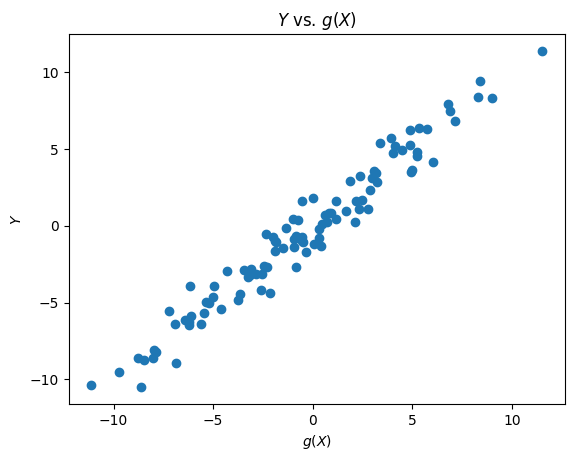

In [4]:
plt.figure()
plt.title(r"$Y$ vs. $g(X)$")
plt.scatter(gX, y)
plt.xlabel(r"$g(X)$")
plt.ylabel(r"$Y$")
plt.show()

In [5]:
print(f"theoretical R^2:, {1 - np.var(ypop - gXpop) / np.var(ypop)}")
print(f"theoretical R^2:, {np.var(gXpop) / np.var(ypop)}")

theoretical R^2:, 0.9641488296136552
theoretical R^2:, 0.9652349567972489


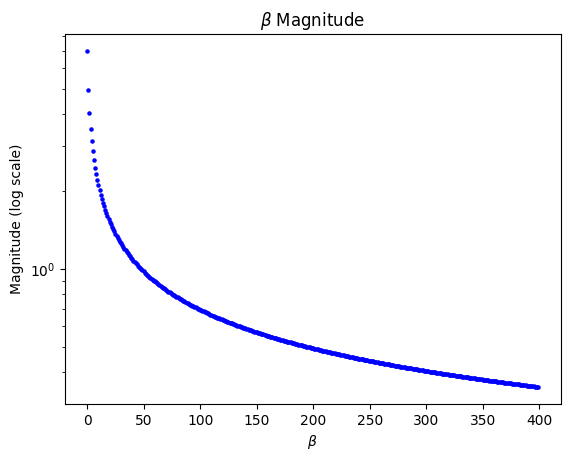

In [6]:
plt.figure()
plt.scatter(range(len(betas)), abs(betas), s=5, color='b')
plt.xlabel(r'$\beta$')
plt.ylabel('Magnitude (log scale)')
plt.title(r'$\beta$ Magnitude')
plt.yscale('log')
plt.show()

## Lasso, Ridge, ElasticNet

We use sklearn's penalized estimators, which choose the penalty parameter via cross-validation (by default 5-fold cross-validation). These methods search over an adaptively chosen grid of hyperparameters. `ElasticNet` allows for a convex combination of `l1` and `l2` penalty and the ratio with `l1_ratio` corresponding to the proportion of the `l1` penalty.

In [7]:
# Regressions
lcv = LassoCV().fit(X, y)
ridge = RidgeCV().fit(X, y)
enet = ElasticNetCV(l1_ratio=0.5).fit(X, y)

We calculate the R-squared on the small test set that we have

In [8]:
r2_lcv = r2_score(ytest, lcv.predict(Xtest))
r2_ridge = r2_score(ytest, ridge.predict(Xtest))
r2_enet = r2_score(ytest, enet.predict(Xtest))
r2_lcv, r2_ridge, r2_enet

(0.02655072188424401, 0.12709104708128116, 0.081949012303983)

We also calculate what the R-squared would be in the population limit (in our case for practical purposes when we have a very very large test sample)

In [9]:
r2_lcv = r2_score(ypop, lcv.predict(Xpop))
r2_ridge = r2_score(ypop, ridge.predict(Xpop))
r2_enet = r2_score(ypop, enet.predict(Xpop))
r2_lcv, r2_ridge, r2_enet

(0.08516638256780762, 0.15925199516890065, 0.15607792574985624)

We can also try this with fitting OLS after Lasso selects variables, but note, this is the wrong post-lasso OLS with cross-validation!

Using a penalty parameter chosen to optimize cross-validation performance for Lasso tends to lead to poor empirical performance when applied to an entirely different procedure, namely Post-Lasso. Instead one would need to run CV on the entire Post-Lasso procedure.

In [10]:
class PostLassoOLS:

    def fit(self, X, y):
        lasso = LassoCV().fit(X, y)
        self.feats_ = np.abs(lasso.coef_) > 1e-6
        self.lr_ = LinearRegression().fit(X[:, self.feats_], y)
        return self

    def predict(self, X):
        return self.lr_.predict(X[:, self.feats_])

    @property
    def coef_(self):
        return self.lr_.coef_

In [11]:
plols = PostLassoOLS().fit(X, y)
r2_score(ypop, plols.predict(Xpop))

0.06572286946546901

## Plug-in Hyperparameter Lasso and Post-Lasso OLS

Here we compute the lasso and ols post lasso using plug-in choices for penalty levels.

\We use "plug-in" tuning with a theoretically valid choice of penalty $\lambda = 2 \cdot c \hat{\sigma} \sqrt{n} \Phi^{-1}(1-\alpha/2p)$, where $c>1$ and $1-\alpha$ is a confidence level, and $\Phi^{-1}$ denotes the quantile function. Under homoskedasticity, this choice ensures that the Lasso predictor is well behaved, delivering good predictive performance under approximate sparsity. In practice, this formula will work well even in the absence of homoskedasticity, especially when the random variables $\epsilon$ and $X$ in the regression equation decay quickly at the tails.

In practice, many people choose to use cross-validation, which is perfectly fine for predictive tasks. However, when conducting inference, to make our analysis valid we will require cross-fitting in addition to cross-validation. As we have not yet discussed cross-fitting, we rely on this theoretically-driven penalty in order to allow for accurate inference in the upcoming notebooks.

We pull an analogue of R's rlasso. Rlasso functionality: it is searching the right set of regressors. This function was made for the case of ***p*** regressors and ***n*** observations where ***p >>>> n***. It assumes that the error is i.i.d. The errors may be non-Gaussian or heteroscedastic.\
The post lasso function makes OLS with the selected ***T*** regressors.
To select those parameters, they use $\lambda$ as variable to penalize\
**Funny thing: the function rlasso was named like that because it is the "rigorous" Lasso.**\
We find a Python code that tries to replicate the main function of hdm r-package. It was made by [Max Huppertz](https://maxhuppertz.github.io/code/). His library is this [repository](https://github.com/maxhuppertz/hdmpy). If not using colab, download its repository and copy this folder to your site-packages folder. In my case it is located here ***C:\Python\Python38\Lib\site-packages*** . We need to install this package ***pip install multiprocess***.

In [12]:
#!git clone https://github.com/maxhuppertz/hdmpy.git
#!pip install multiprocess

In [13]:
# We wrap the package so that it has the familiar sklearn API
import sys
sys.path.insert(1, "./hdmpy")

# import sys, os
# sys.path.insert(0, os.path.abspath('hdmpy'))
import hdmpy


class RLasso(BaseEstimator):

    def __init__(self, *, post=True):
        self.post = post

    def fit(self, X, y):
        self.rlasso_ = hdmpy.rlasso(X, y, post=self.post)
        return self

    def predict(self, X):
        return X @ np.array(self.rlasso_.est['beta']).flatten() + np.array(self.rlasso_.est['intercept'])

In [14]:
rlasso = RLasso(post=False).fit(X, y)
rlasso_post = RLasso(post=True).fit(X, y)

In [15]:
r2_rlasso = r2_score(ytest, rlasso.predict(Xtest))
r2_rlasso_post = r2_score(ytest, rlasso_post.predict(Xtest))
r2_rlasso, r2_rlasso_post

(0.09901947528311317, -0.0035425021052202244)

In [16]:
r2_rlasso = r2_score(ypop, rlasso.predict(Xpop))
r2_rlasso_post = r2_score(ypop, rlasso_post.predict(Xpop))
r2_rlasso, r2_rlasso_post

(0.10179193843706491, -0.011082676078811193)

## LAVA: Dense + Sparse Coefficients

Now let's try the LAVA estimator

In [17]:
# We construct an sklearn API estimator that implements the LAVA method


class Lava(BaseEstimator):

    def __init__(self, *, alpha1=1, alpha2=1, iterations=5):
        self.alpha1 = alpha1  # l1 penalty
        self.alpha2 = alpha2
        self.iterations = iterations

    def fit(self, X, y):
        ridge = Ridge(self.alpha2).fit(X, y)
        lasso = Lasso(self.alpha1).fit(X, y - ridge.predict(X))

        for _ in range(self.iterations - 1):
            ridge = ridge.fit(X, y - lasso.predict(X))
            lasso = lasso.fit(X, y - ridge.predict(X))

        self.lasso_ = lasso
        self.ridge_ = ridge
        return self

    def predict(self, X):
        return self.lasso_.predict(X) + self.ridge_.predict(X)

In [18]:
lava = GridSearchCV(Lava(), {'alpha1': np.logspace(-4, 4, 20), 'alpha2': np.logspace(-4, 4, 20)},
                    scoring='r2', n_jobs=-1)
lava.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lava()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha1': array([1.0000...00000000e+04]), 'alpha2': array([1.0000...00000000e+04])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;-

In [19]:
lava.best_estimator_

,alpha1,np.float64(0.0001)
,alpha2,np.float64(11.288378916846883)
,iterations,5


In [20]:
r2_lava = r2_score(ytest, lava.predict(Xtest))
r2_lava

0.30321187529049953

In [21]:
r2_lava = r2_score(ypop, lava.predict(Xpop))
r2_lava

0.3655680828327832

## Summarizing Results

In [22]:
df = pd.DataFrame({'LassoCV': [r2_lcv],
                   'RidgeCV': [r2_ridge],
                   'ElasticNetCV': [r2_enet],
                   'RLasso': [r2_rlasso],
                   'RLassoOLS': [r2_rlasso_post],
                   'Lava': [r2_lava]}).T
df.columns = ['Population R-squared']
df

,Population R-squared
LassoCV,0.085166
RidgeCV,0.159252
ElasticNetCV,0.156078
RLasso,0.101792
RLassoOLS,-0.011083
Lava,0.365568


In [23]:
print(df)

              Population R-squared
LassoCV                   0.085166
RidgeCV                   0.159252
ElasticNetCV              0.156078
RLasso                    0.101792
RLassoOLS                -0.011083
Lava                      0.365568


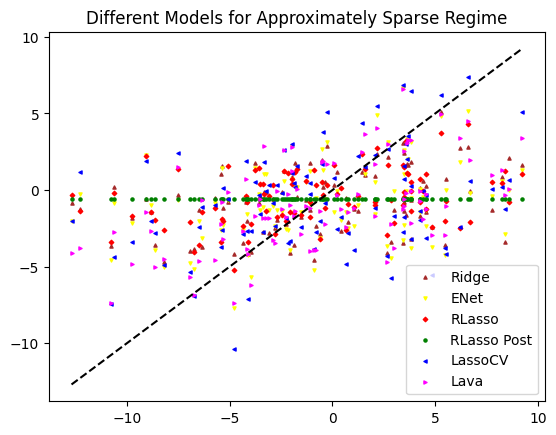

In [24]:
plt.figure()
plt.title("Different Models for Approximately Sparse Regime")
# 45 degree line
plt.plot([np.min(gXtest), np.max(gXtest)], [np.min(gXtest), np.max(gXtest)], color='black', linestyle='--')

# different models
plt.scatter(gXtest, ridge.predict(Xtest), marker='^', c='brown', s=5, label='Ridge')
plt.scatter(gXtest, enet.predict(Xtest), marker='v', c='yellow', s=5, label='ENet')
plt.scatter(gXtest, rlasso.predict(Xtest), marker='D', c='red', s=5, label='RLasso')
plt.scatter(gXtest, rlasso_post.predict(Xtest), marker='o', c='green', s=5, label='RLasso Post')
plt.scatter(gXtest, lcv.predict(Xtest), marker='<', c='blue', s=5, label='LassoCV')
plt.scatter(gXtest, lava.predict(Xtest), marker='>', c='magenta', s=5, label='Lava')
plt.legend(loc='lower right')

plt.show()

## Data Generating Process: Dense Coefficients

In [25]:
n = 100
p = 400
X, y, gX, Xtest, ytest, gXtest, Xpop, ypop, gXpop, betas = gen_data(n, p, regime="dense")

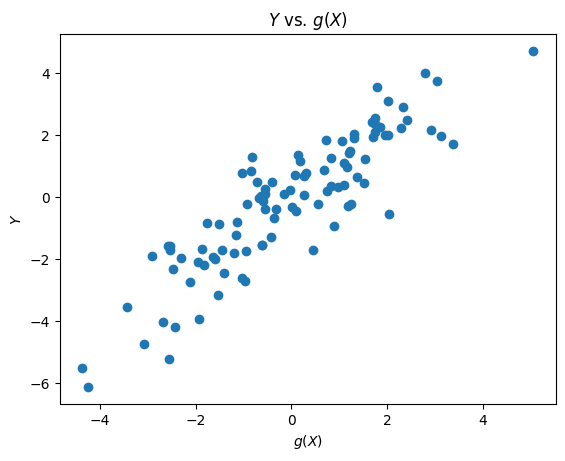

In [26]:
plt.figure()
plt.title(r"$Y$ vs. $g(X)$")
plt.scatter(gX, y)
plt.xlabel(r"$g(X)$")
plt.ylabel(r"$Y$")
plt.show()

In [27]:
print(f"theoretical R^2:, {1 - np.var(ypop - gXpop) / np.var(ypop)}")
print(f"theoretical R^2:, {np.var(gXpop) / np.var(ypop)}")

theoretical R^2:, 0.7925187792316306
theoretical R^2:, 0.7929488376437579


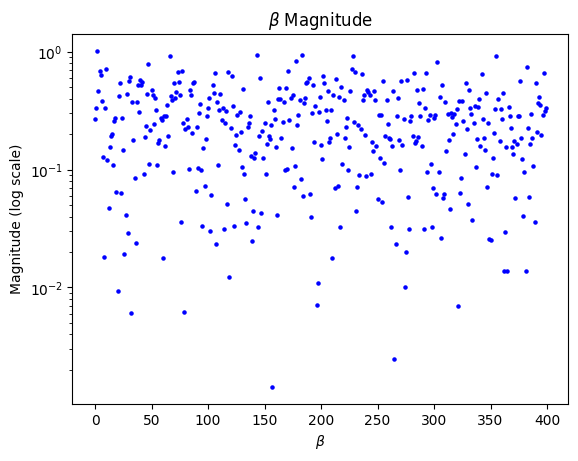

In [28]:
plt.figure()
plt.scatter(range(len(betas)), abs(betas), s=5, color='b')
plt.xlabel(r'$\beta$')
plt.ylabel('Magnitude (log scale)')
plt.title(r'$\beta$ Magnitude')
plt.yscale('log')
plt.show()

In [29]:
# Regressions
lcv = LassoCV().fit(X, y)
ridge = RidgeCV(alphas=(1, 10, 25, 50, 100)).fit(X, y)
enet = ElasticNetCV(l1_ratio=0.5).fit(X, y)
rlasso = RLasso(post=False).fit(X, y)
rlasso_post = RLasso(post=True).fit(X, y)
lava = GridSearchCV(Lava(), {'alpha1': np.logspace(-4, 4, 20), 'alpha2': np.logspace(-4, 4, 20)},
                    scoring='r2', n_jobs=-1).fit(X, y)

In [30]:
r2_lcv = r2_score(ypop, lcv.predict(Xpop))
r2_ridge = r2_score(ypop, ridge.predict(Xpop))
r2_enet = r2_score(ypop, enet.predict(Xpop))
r2_rlasso = r2_score(ypop, rlasso.predict(Xpop))
r2_rlasso_post = r2_score(ypop, rlasso_post.predict(Xpop))
r2_lava = r2_score(ypop, lava.predict(Xpop))

In [31]:
df = pd.DataFrame({'LassoCV': [r2_lcv],
                   'RidgeCV': [r2_ridge],
                   'ElasticNetCV': [r2_enet],
                   'RLasso': [r2_rlasso],
                   'RLassoOLS': [r2_rlasso_post],
                   'Lava': [r2_lava]}).T
df.columns = ['Population R-squared']
df

,Population R-squared
LassoCV,-0.016155
RidgeCV,0.105809
ElasticNetCV,0.037059
RLasso,-0.015372
RLassoOLS,-0.004822
Lava,0.061246


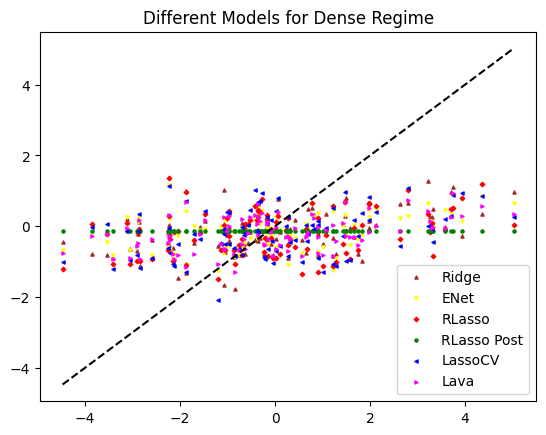

In [32]:
plt.figure()
plt.title("Different Models for Dense Regime")
# 45 degree line
plt.plot([np.min(gXtest), np.max(gXtest)], [np.min(gXtest), np.max(gXtest)], color='black', linestyle='--')

# different models
plt.scatter(gXtest, ridge.predict(Xtest), marker='^', c='brown', s=5, label='Ridge')
plt.scatter(gXtest, enet.predict(Xtest), marker='v', c='yellow', s=5, label='ENet')
plt.scatter(gXtest, rlasso.predict(Xtest), marker='D', c='red', s=5, label='RLasso')
plt.scatter(gXtest, rlasso_post.predict(Xtest), marker='o', c='green', s=5, label='RLasso Post')
plt.scatter(gXtest, lcv.predict(Xtest), marker='<', c='blue', s=5, label='LassoCV')
plt.scatter(gXtest, lava.predict(Xtest), marker='>', c='magenta', s=5, label='Lava')
plt.legend(loc='lower right')

plt.show()

## Data Generating Process: Approximately Sparse + Small Dense Part

In [33]:
n = 100
p = 400
X, y, gX, Xtest, ytest, gXtest, Xpop, ypop, gXpop, betas = gen_data(n, p, regime="sparsedense")

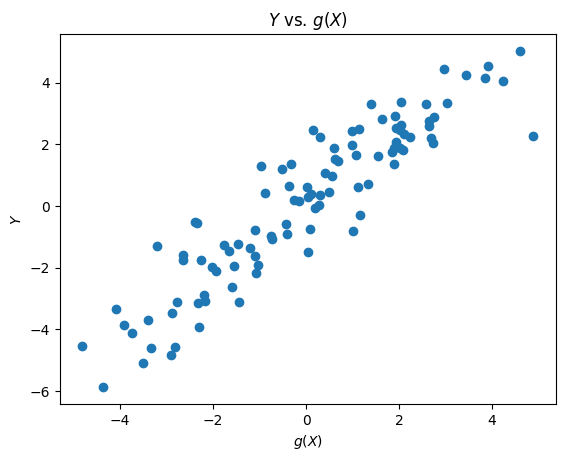

In [34]:
plt.figure()
plt.title(r"$Y$ vs. $g(X)$")
plt.scatter(gX, y)
plt.xlabel(r"$g(X)$")
plt.ylabel(r"$Y$")
plt.show()

In [35]:
print(f"theoretical R^2:, {1 - np.var(ypop - gXpop) / np.var(ypop)}")
print(f"theoretical R^2:, {np.var(gXpop) / np.var(ypop)}")

theoretical R^2:, 0.8204350157384916
theoretical R^2:, 0.8210944717665257


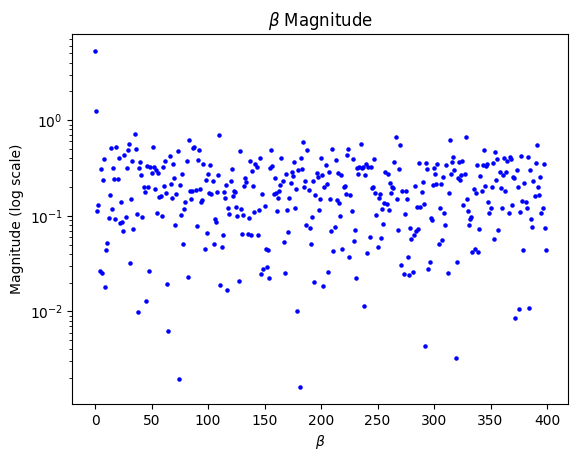

In [36]:
plt.figure()
plt.scatter(range(len(betas)), abs(betas), s=5, color='b')
plt.xlabel(r'$\beta$')
plt.ylabel('Magnitude (log scale)')
plt.title(r'$\beta$ Magnitude')
plt.yscale('log')
plt.show()

In [37]:
# Regressions
lcv = LassoCV().fit(X, y)
ridge = RidgeCV().fit(X, y)
enet = ElasticNetCV(l1_ratio=0.5).fit(X, y)
rlasso = RLasso(post=False).fit(X, y)
rlasso_post = RLasso(post=True).fit(X, y)
lava = GridSearchCV(Lava(), {'alpha1': np.logspace(-4, 4, 20), 'alpha2': np.logspace(-4, 4, 20)},
                    scoring='r2', n_jobs=-1).fit(X, y)

In [38]:
r2_lcv = r2_score(ypop, lcv.predict(Xpop))
r2_ridge = r2_score(ypop, ridge.predict(Xpop))
r2_enet = r2_score(ypop, enet.predict(Xpop))
r2_rlasso = r2_score(ypop, rlasso.predict(Xpop))
r2_rlasso_post = r2_score(ypop, rlasso_post.predict(Xpop))
r2_lava = r2_score(ypop, lava.predict(Xpop))

In [39]:
df = pd.DataFrame({'LassoCV': [r2_lcv],
                   'RidgeCV': [r2_ridge],
                   'ElasticNetCV': [r2_enet],
                   'RLasso': [r2_rlasso],
                   'RLassoOLS': [r2_rlasso_post],
                   'Lava': [r2_lava]}).T
df.columns = ['Population R-squared']
df

,Population R-squared
LassoCV,0.316894
RidgeCV,0.172348
ElasticNetCV,0.303202
RLasso,0.400337
RLassoOLS,0.328805
Lava,0.428707


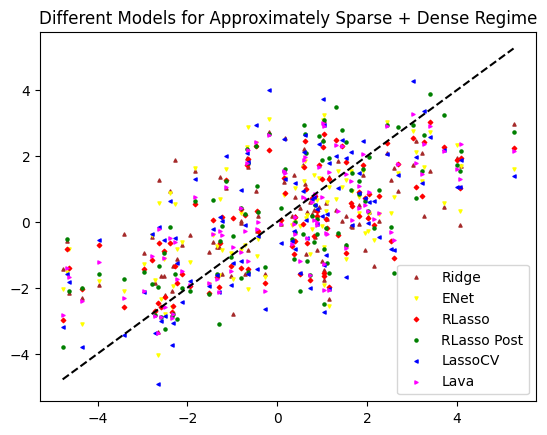

In [40]:
plt.figure()
plt.title("Different Models for Approximately Sparse + Dense Regime")
# 45 degree line
plt.plot([np.min(gXtest), np.max(gXtest)], [np.min(gXtest), np.max(gXtest)], color='black', linestyle='--')

# different models
plt.scatter(gXtest, ridge.predict(Xtest), marker='^', c='brown', s=5, label='Ridge')
plt.scatter(gXtest, enet.predict(Xtest), marker='v', c='yellow', s=5, label='ENet')
plt.scatter(gXtest, rlasso.predict(Xtest), marker='D', c='red', s=5, label='RLasso')
plt.scatter(gXtest, rlasso_post.predict(Xtest), marker='o', c='green', s=5, label='RLasso Post')
plt.scatter(gXtest, lcv.predict(Xtest), marker='<', c='blue', s=5, label='LassoCV')
plt.scatter(gXtest, lava.predict(Xtest), marker='>', c='magenta', s=5, label='Lava')
plt.legend(loc='lower right')

plt.show()

# Experiments

## Different decay rates

In [ ]:
decay_rates = np.logspace(-1/2, 1, 5)

n = 100
p = 400

results = []

for decay_rate in decay_rates:
    print("- Decay rate:", decay_rate)
    X, y, gX, Xtest, ytest, gXtest, Xpop, ypop, gXpop, betas = gen_data(n, p, regime="sparse", decay_rate=decay_rate)

    # print(f"theoretical R^2:, {1 - np.var(ypop - gXpop) / np.var(ypop)}")
    # print(f"theoretical R^2:, {np.var(gXpop) / np.var(ypop)}")

    # Regressions
    lcv = LassoCV().fit(X, y)
    ridge = RidgeCV().fit(X, y)
    enet = ElasticNetCV(l1_ratio=0.5).fit(X, y)
    rlasso = RLasso(post=False).fit(X, y)
    rlasso_post = RLasso(post=True).fit(X, y)
    lava = GridSearchCV(Lava(), {'alpha1': np.logspace(-4, 4, 20), 'alpha2': np.logspace(-4, 4, 20)},
                        scoring='r2', n_jobs=-1).fit(X, y)

    r2_lcv = r2_score(ypop, lcv.predict(Xpop))
    r2_ridge = r2_score(ypop, ridge.predict(Xpop))
    r2_enet = r2_score(ypop, enet.predict(Xpop))
    r2_rlasso = r2_score(ypop, rlasso.predict(Xpop))
    r2_rlasso_post = r2_score(ypop, rlasso_post.predict(Xpop))
    r2_lava = r2_score(ypop, lava.predict(Xpop))

    df = pd.DataFrame({'LassoCV': [r2_lcv],
                    'RidgeCV': [r2_ridge],
                    'ElasticNetCV': [r2_enet],
                    'RLasso': [r2_rlasso],
                    'RLassoOLS': [r2_rlasso_post],
                    'Lava': [r2_lava]}).T
    df.columns = ['Population R-squared']
    results.append(df)

- Decay rate: 0.31622776601683794
- Decay rate: 0.33932217718953284
- Decay rate: 0.36410319493106746
- Decay rate: 0.3906939937054617
- Decay rate: 0.4192267435236917
- Decay rate: 0.4498432668969446
- Decay rate: 0.4826957437677871
- Decay rate: 0.5179474679231212
- Decay rate: 0.5557736586486878
- Decay rate: 0.5963623316594643
- Decay rate: 0.6399152336349265
- Decay rate: 0.6866488450043001
- Decay rate: 0.7367954559661629
- Decay rate: 0.79060432109077
- Decay rate: 0.848342898244072
- Decay rate: 0.9102981779915219
- Decay rate: 0.976778110089489
- Decay rate: 1.0481131341546859
- Decay rate: 1.1246578221198196
- Decay rate: 1.2067926406393286
- Decay rate: 1.2949258422052625
- Decay rate: 1.3894954943731375
- Decay rate: 1.490971657184064
- Decay rate: 1.599858719606058
- Decay rate: 1.7166979066078603
- Decay rate: 1.842069969326716
- Decay rate: 1.9765980717016338
- Decay rate: 2.120950887920191
- Decay rate: 2.2758459260747883
- Decay rate: 2.442053094548651
- Decay rate: 2.

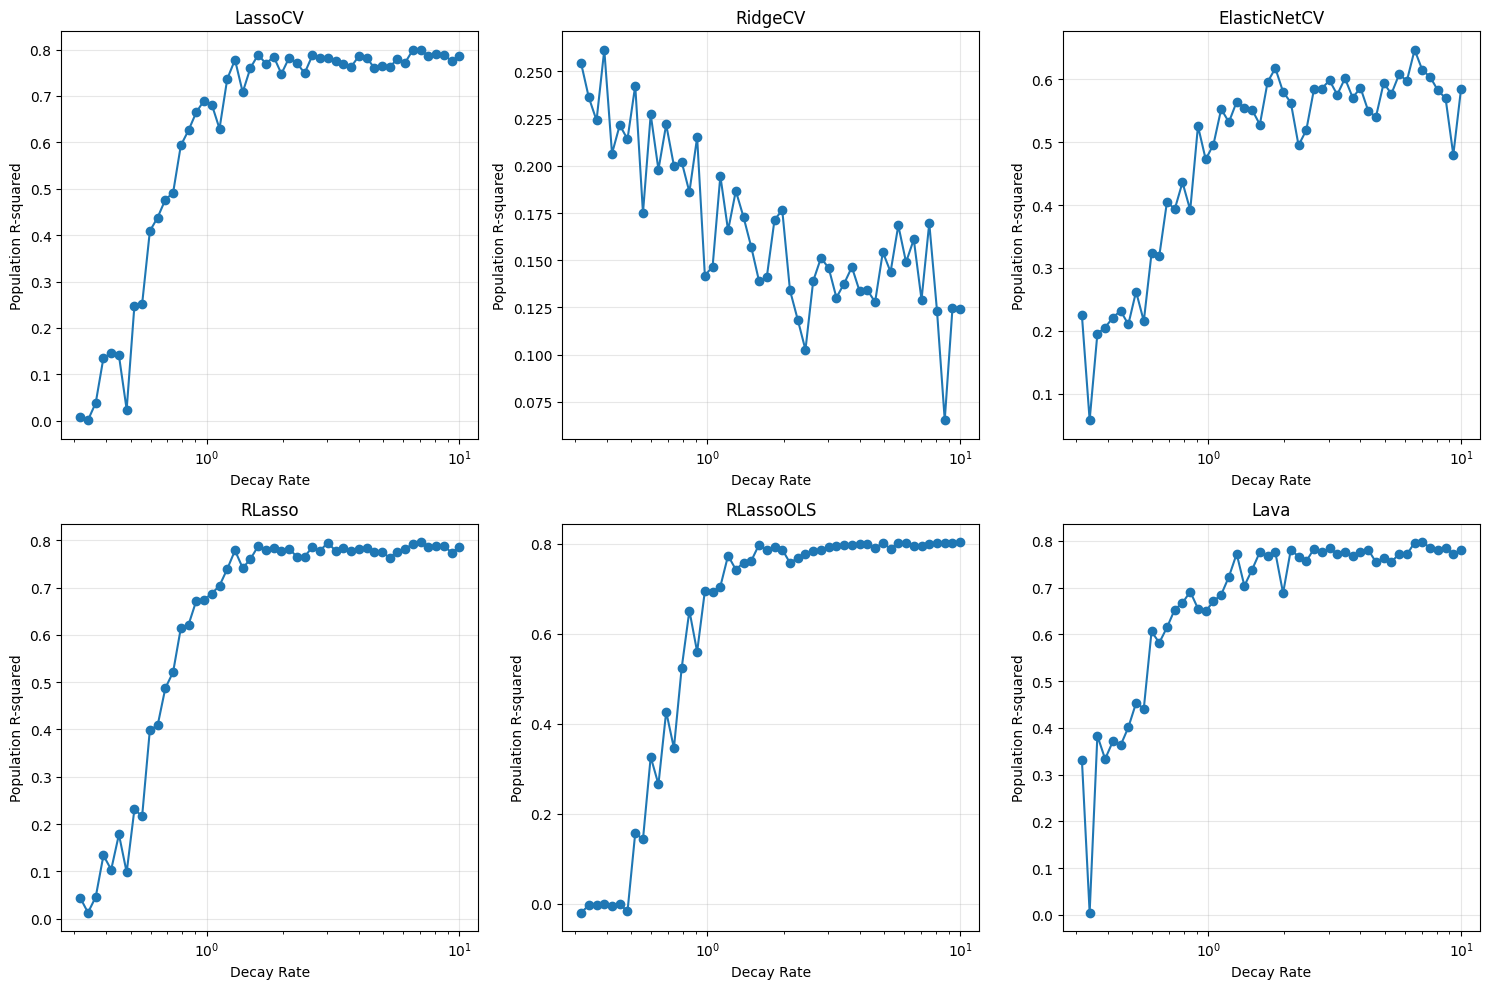

In [42]:
# Create plots for each regression type

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

regression_types = ['LassoCV', 'RidgeCV', 'ElasticNetCV', 'RLasso', 'RLassoOLS', 'Lava']

for idx, reg_type in enumerate(regression_types):
    r2_scores = [result.loc[reg_type, 'Population R-squared'] for result in results]
    axes[idx].plot(decay_rates, r2_scores, marker='o')
    axes[idx].set_xlabel('Decay Rate')
    axes[idx].set_ylabel('Population R-squared')
    axes[idx].set_title(reg_type)
    axes[idx].set_xscale('log')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Different error distributions

In [ ]:
dists = ["normal", "uniform", "laplace", "beta"]
n_sim = 5  # number of simulations per distribution

n = 100
p = 400


dist_results = []

for dist in dists: 
    print("- Distribution:", dist)
    
    # Store R2 for each simulation
    r2_all = {
        'LassoCV': [],
        'RidgeCV': [],
        'ElasticNetCV': [],
        'RLasso': [],
        'RLassoOLS': [],
        'Lava': []
    }
    
    for sim in range(n_sim):
        X, y, gX, Xtest, ytest, gXtest, Xpop, ypop, gXpop, betas = gen_data(
            n, p, regime="sparse", distribution=dist
        )

        # Regressions
        lcv = LassoCV().fit(X, y)
        ridge = RidgeCV().fit(X, y)
        enet = ElasticNetCV(l1_ratio=0.5).fit(X, y)
        rlasso = RLasso(post=False).fit(X, y)
        rlasso_post = RLasso(post=True).fit(X, y)
        lava = GridSearchCV(
            Lava(), 
            {'alpha1': np.logspace(-4, 4, 20), 'alpha2': np.logspace(-4, 4, 20)},
            scoring='r2', n_jobs=-1
        ).fit(X, y)

        # Compute R2
        r2_all['LassoCV'].append(r2_score(ypop, lcv.predict(Xpop)))
        r2_all['RidgeCV'].append(r2_score(ypop, ridge.predict(Xpop)))
        r2_all['ElasticNetCV'].append(r2_score(ypop, enet.predict(Xpop)))
        r2_all['RLasso'].append(r2_score(ypop, rlasso.predict(Xpop)))
        r2_all['RLassoOLS'].append(r2_score(ypop, rlasso_post.predict(Xpop)))
        r2_all['Lava'].append(r2_score(ypop, lava.predict(Xpop)))

    # Average R2 over simulations
    df_avg = pd.DataFrame({k: [np.mean(v)] for k, v in r2_all.items()}).T
    df_avg.columns = ['Average Population R-squared']
    dist_results.append(df_avg)

- Distribution: normal
- Distribution: uniform
- Distribution: laplace
- Distribution: beta


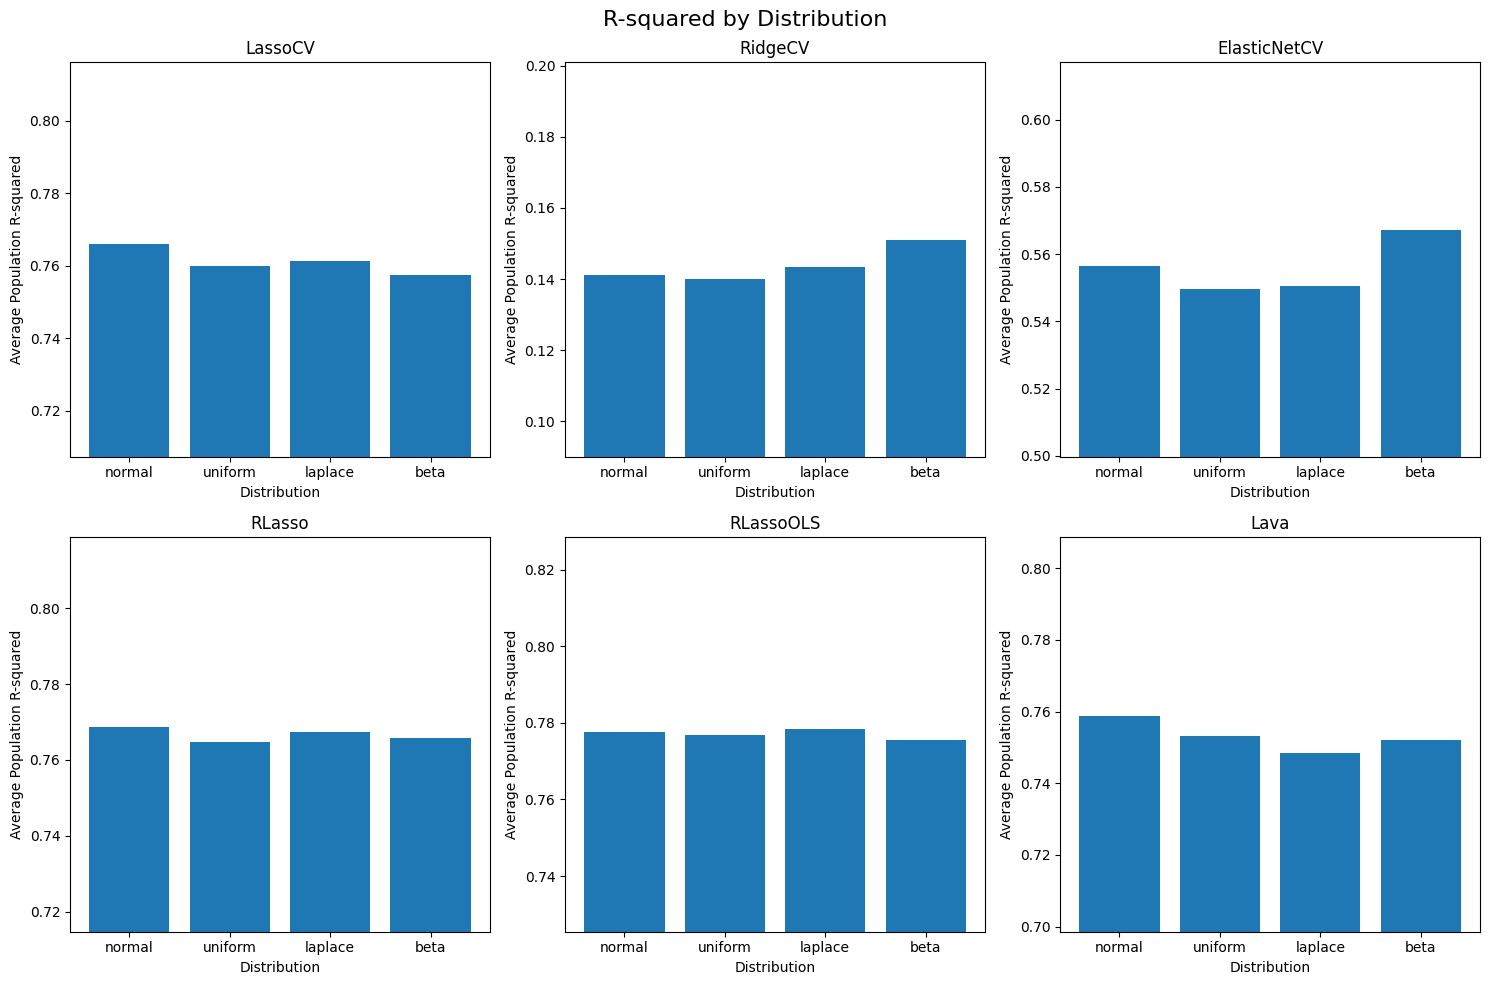

In [44]:
# Now plot
plt.figure(figsize=(15, 10))
plt.suptitle('R-squared by Distribution', fontsize=16)

for idx, reg_type in enumerate(regression_types, 1):
    plt.subplot(2, 3, idx)
    r2_values = [result.loc[reg_type, 'Average Population R-squared'] for result in dist_results]
    plt.bar(dists, r2_values)
    plt.xlabel('Distribution')
    plt.ylabel('Average Population R-squared')
    plt.title(reg_type)
    plt.ylim([min(r2_values) - 0.05, max(r2_values) + 0.05])

plt.tight_layout()
plt.show()

# Results

## 'Sparse', but slow decay ($p^{-1/2}$)

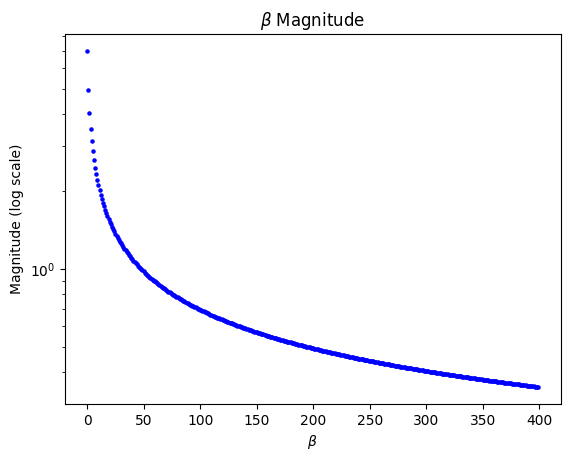

When $\beta$ decays slowly, the variable selection of Lasso does negatively affect predictive performance. We have similar performance as in the sparse + dense case as numerous coefficients are less important but many still not negligible.

| Model        | Population R-squared |
|--------------|----------------------|
| LassoCV      | 0.178395             |
| RidgeCV      | 0.265896             |
| ElasticNetCV | 0.309350             |
| RLasso       | 0.249367             |
| RLassoOLS    | 0.166513             |
| Lava         | 0.501253             |




## Different decay rates

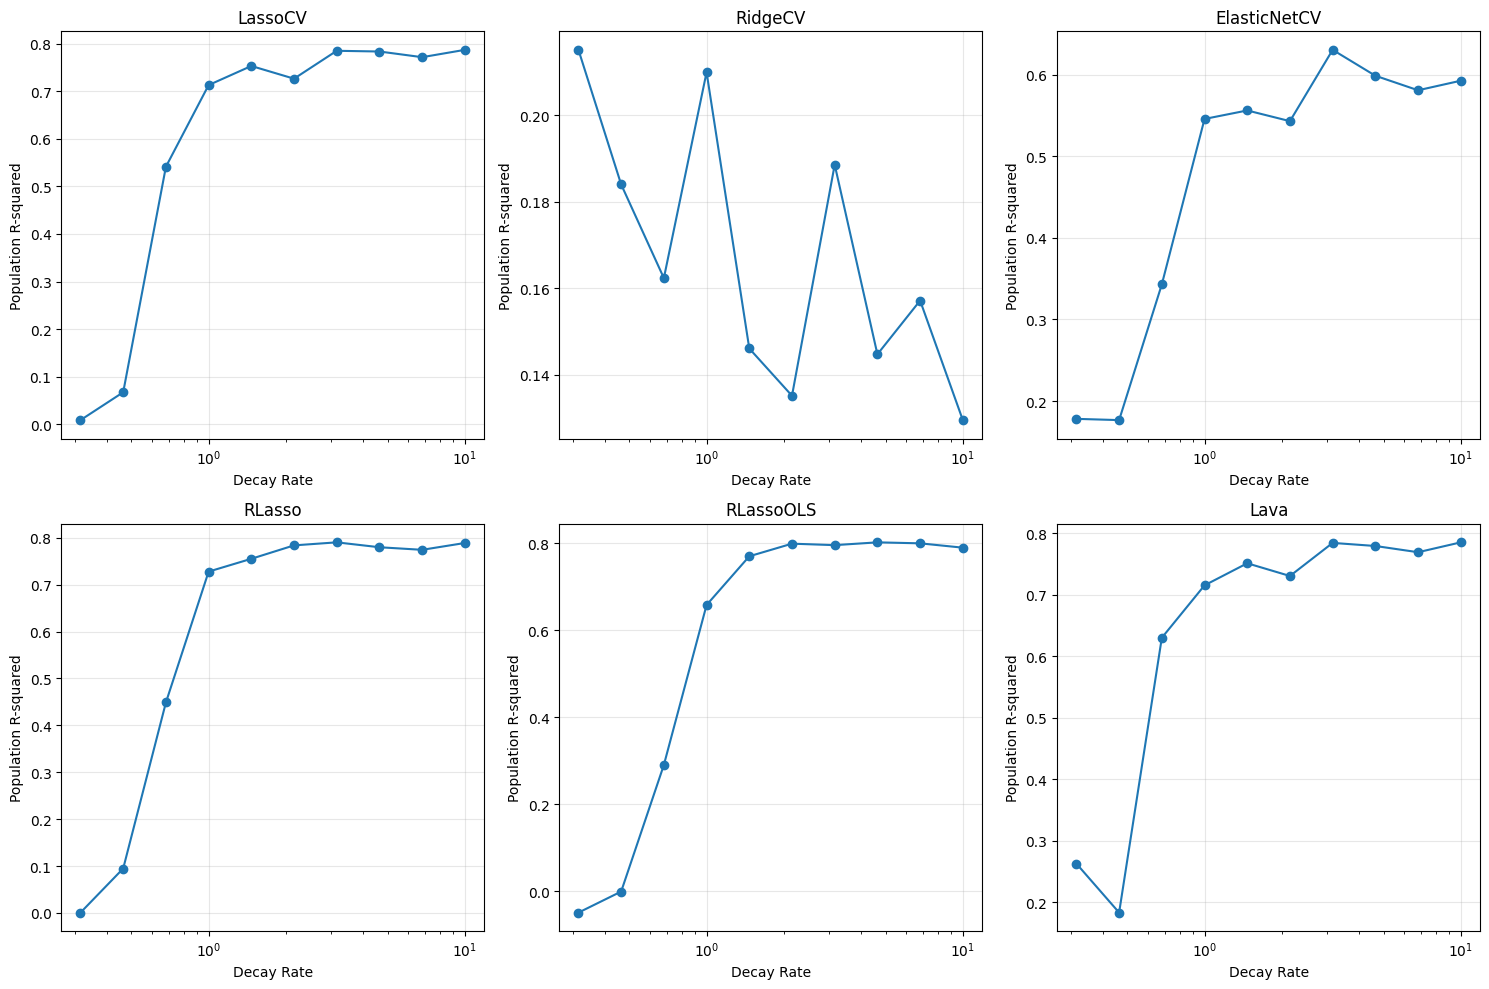

- **Lasso**:
Poor when decay is slow (sparse + dense), very good when decay is fast (sparse).\
Lasso imposes a $L_1$ penalty that encourages zero coefficients and thus induces sparsity. In the dense + sparse case when many predictors matter, Lasso removes smaller but relevant coefficients which causes a high bias and worsens out of sample predictive performance (low $R^2$). When underlying true coefficients are sparse, Lasso identifies coefficients which are not relevant. In particular under approximate sparsity (decay rate greater 1/2), Thm. 3.2.1 from the lecture notes says that Lasso approximately finds the important predictors and approximates the BLP (both for CV/theoretical regularization parameter).
Lasso with cross-validation or a theoretical regularization perform similarly well (the latter is slightly more stable as it doesnt rely on noisy data for penalty calibration) whereas Post-Lasso improves overall slightly in the sparse regime as refitting the OLS on the selected support removes the shrinkage bias while keeping the dimensionality reduction.


- **Ridge**:
Better in dense + sparse regime but generally poor.\
Since the $L^2$ penalty does not perform variable selection, ridge doesn't perform well in the sparse regime as it keeps many irrelevant predictors. Theoretically, it is instead well-suited for dense data but our $\beta$'s are generated with a significant tail of less important coefficients ($\frac{1}{j^{\text{decay\_ rate}}}$), i.e., dense + sparse and ridge cannot exploit the sparsity that is clearly present in the data even at slow decay rates.

- **ElNet**:
Intermediate between Ridge and Lasso and hence more stable for dense + sparse data.\
ElNet has some sparsity adjustment but at the same time is better adapted to more dense data and hence performes better in the dense + sparse regime, as expected. In the sparse case however, the added $L^2$ penalty reduces variable selection and it performs worse than pure Lasso. 

- **Lava**:
Improves in sparse + dense regime without sacrificing much on sparse data.\
The latent variable decomposition into a sparse and a dense part is designed for mixture structures adapts more effectively than ElNet to both regimes and performs almost as good as Lasso on sparse data despite no variable selection.

## Different Error Distributions

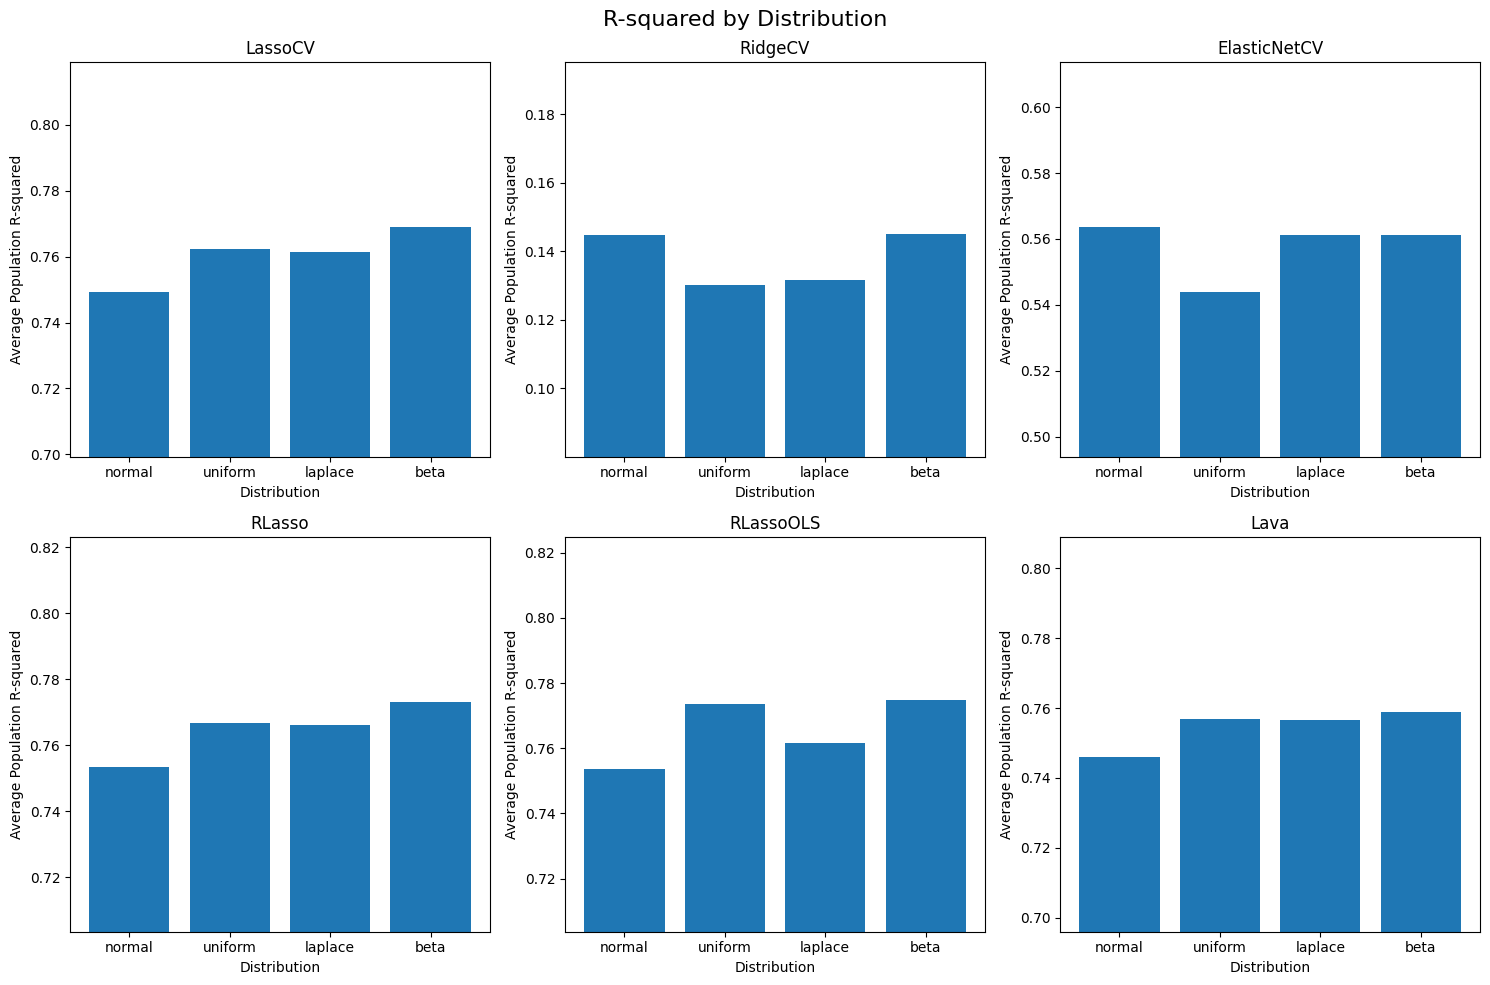

Note, despite averaging multiple runs, the $R^2$ still changes a lot between different simulation runs and much larger n_sim would be needed to get a stable result. However, some general comments:

- Lasso methods perform similarly well across different error distributions (despite heavy tailed/skewed). This makes sense since Theorem 3.2.1 from the lecture holds indpendent of functional form assumptions about the error term and I have normalized the variance to 1.
- Ridge performs still significantly worse. This confirms that the performance between $L^1$ and $L^2$ penalty depends mainly on the structure of the coefficients (Ridge is mismatched with the true sparse $\beta$) and not on distributional assumptions about the error term.
- As expected ElNet which combines $L^1$ and $L^2$ penalty always performs in between Lasso and Ridge, similarly Lava

## Conclusion

In high-dimensional prediction, structural match between penalty and true parameter dominates distributional assumptions on noise (in some standard cases). However, Lava can be deployed most flexibly as it alsways performs reasonably well compared to all other